# Install packages

In [1]:
!pip install swig mediapy
!pip install mujoco==3.1.4
!pip install torch torchrl
!pip install gymnasium[box2d,mujoco]==0.28.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 41.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 24.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 123.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 93.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3

# Imports and Functions

In [2]:
# Imports
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation, rc
from ipywidgets import interact, widgets
# Change to glfw when on Mac. This might fuck up the lighting.
%env MUJOCO_GL=egl
import mujoco
import mujoco.viewer
import mediapy as media

import torch
from torch import nn
import torch.nn.functional as F
from tensordict import TensorDict
from torchrl.data import CompositeSpec, BoundedTensorSpec, UnboundedContinuousTensorSpec
from torchrl.envs.model_based import ModelBasedEnvBase
from torchrl.modules import SafeModule
from torchrl.modules import CEMPlanner
from torchrl.modules import WorldModelWrapper
from torchrl.data import TensorDictReplayBuffer

env: MUJOCO_GL=egl


/usr/local/lib/python3.11/dist-packages/torchrl/data/replay_buffers/samplers.py:34: UserWarning: Failed to import torchrl C++ binaries. Some modules (eg, prioritized replay buffers) may not work with your installation. This is likely due to a discrepancy between your package version and the PyTorch version. Make sure both are compatible. Usually, torchrl majors follow the pytorch majors within a few days around the release. For instance, TorchRL 0.5 requires PyTorch 2.4.0, and TorchRL 0.6 requires PyTorch 2.5.0.
  warnings.warn(EXTENSION_WARNING)


what is control gain?

In [3]:
class MujocoCartPoleEnv(gym.Env):
    def __init__(self, m = 2, M = 5, l = 0.5, g = 9.81, k = 100, dt = 0.02, end_on_failure = True):
        self.model = self._get_mj_model(m,M,l,g,k,dt)
        self.data = mujoco.MjData(self.model)
        self.renderer = mujoco.Renderer(self.model)
        self.truncate = 1000
        self.action_space = gym.spaces.Box(low=-1, high=1, shape=(self.model.nu,))
        self.observation_space = gym.spaces.Box(low=-np.inf, high=np.inf, shape=(self.model.nq + self.model.nv,))
        self.end_on_failure = end_on_failure
        self.reset()

    def reset(self):
        mujoco.mj_resetData(self.model, self.data)
        self.data.qvel = 0.0*np.random.randn(2) # velocities
        self.data.qpos = 0.1*np.random.randn(2) # positions
        self.timestep = 0
        return self.get_state(), {}

    def set_state(self, state):
        self.data.qpos = state[:self.model.nq]
        self.data.qvel = state[self.model.nq:]

    def get_state(self):
        return np.concatenate([self.data.qpos, self.data.qvel])

    def step(self, action):
        self.data.ctrl = action
        mujoco.mj_step(self.model, self.data)
        next_state = self.get_state()
        reward = self._calculate_reward()
        terminal = self._is_done()
        truncated = self.timestep >= self.truncate
        info = {}  # Additional information (optional)
        self.timestep += 1
        return (next_state, reward, terminal, truncated, info)

    def render(self):
        self.renderer.update_scene(self.data)
        return self.renderer.render()

    def _calculate_reward(self):
        # Calculate reward based on the current state (optional)
        return int(self.data.qpos[1] > - np.pi/12 and self.data.qpos[1] < np.pi/12)

    def _is_done(self):
        # Check if the episode is done based on the current state (optional)
        if self.end_on_failure:
            return (self.data.qpos[1] < - np.pi/12 or self.data.qpos[1] > np.pi/12)
        return False

    # return a mujoco model with the given physical parameters
    @staticmethod
    def _get_mj_model(m,M,l,g,k,dt):
        xml = f"""
        <mujoco model='test_cartpole'>
            <compiler inertiafromgeom='true' coordinate='local'/>

            <size nkey="1"/>

            <option timestep='{dt}' integrator="RK4" gravity='0 0 {-g}'/>

            <default>
            <joint damping='0.0' solreflimit='.08 1'/>
            <geom contype='0' friction='0. 0. 0.'/>
            </default>

            <worldbody>
            <camera name='fixed' pos='0 -2.5 0' quat='0.707 0.707 0 0'/>
            <light name="top" castshadow="false"/>
            <geom name='floor' pos='0 0 -1' size='4 4 4' type='plane' />
            <geom name='rail1' type='capsule' pos='0 .07 0' quat='0.707 0 0.707 0'
                    size='0.02 2.2' />
            <geom name='rail2' type='capsule' pos='0 -.07 0' quat='0.707 0 0.707 0'
                    size='0.02 2.2' />
            <body name='cart' pos='0 0 0'>
                <camera name='cart' pos='0 -2.5 0' quat='0.707 0.707 0 0' />
                <joint name='slider' type='slide' limited='true' pos='0 0 0'
                        axis='1 0 0' range='-2 2' />
                <geom name='cart' type='box' pos='0 0 0'
                        mass='{M}' size='0.2 0.1 0.05' rgba='0.7 0.7 0 1' />
                <site name='cart sensor' type='box' pos='0 0 0'
                        size='0.2 0.1 0.05' rgba='0.7 0.7 0 0' />
                <body name='pole' pos='0 0 0'>
                <camera name='pole'  pos='0 -2.5 0' quat='0.707 0.707 0 0' />
                <joint name='hinge' type='hinge' pos='0 0 0' axis='0 1 0'/>
                <geom name='cpole' type='capsule' fromto='0 0 0 0 0 {l}'
                        mass='0' size='0.01 {l}' rgba='0 0.7 0.7 1' />
                <geom type='sphere' size='.05' name='tip' mass='{m}' pos='.001 0 {l}'/>
                </body>
            </body>
            </worldbody>

            <actuator>
            <motor name='slide' joint='slider' gear='{k}' ctrllimited='true' ctrlrange='-1 1' />
            </actuator>

        </mujoco>
        """
        return mujoco.MjModel.from_xml_string(xml)

In [4]:
def render_episode(policy, env):
	frames = []
	score = 0
	state = env.get_state()
	terminated = truncated = False
	while not terminated and not truncated:
		frame = env.render()
		frames.append(frame)
		action = policy(state)
		state, reward, terminated, truncated, _ = env.step(action)
		score += reward
	env.close()
	print(f"Finished episode. Cummulative Return: {score}")
	media.show_video(frames, fps=100, loop=True)

# Model-Predictive Control
Model Predictive Control (MPC) is a control strategy that utilizes a predictive model of the system dynamics to make optimal control decisions. Unlike traditional control methods like Linear Quadratic Regulator (LQR), which rely on a fixed control law, MPC considers the future behavior of the system and optimizes the control inputs over a finite time horizon. This allows MPC to handle complex systems with constraints and uncertainties more effectively. While LQR provides optimal control for linear systems with known dynamics, MPC can handle nonlinear systems and adapt to changing operating conditions. Additionally, MPC can incorporate constraints on control inputs, states, and outputs, ensuring that the system operates within safe and desired limits. By considering the future consequences of control actions, MPC enables better performance and robustness in various applications, such as robotics, process control, and autonomous vehicles.

## Forward Models
Forward dynamics models are mathematical models that describe the behavior of a system over time. In the context of robotics and control systems, forward dynamics models are used to predict the future state of a system given its current state and the applied control inputs. These models capture the relationships between the system's state variables, such as position, velocity, and acceleration, and the forces or torques acting on the system. By simulating the dynamics of a system forward in time, forward dynamics models enable us to understand and analyze the system's behavior, plan optimal control strategies, and simulate the system's response to different inputs.

In [5]:
# Forward model that takes in a state and an action to predict the next action using the non-linear equations of motion that we derived
# in the control exercise. The model uses a simpler integration method than MuJoCo, resulting in different trajectories.
def predict_next_states(states, actions):
	m = 2 # pole mass
	M = 5  # Mass
	l = 0.5  # pole length
	g = 9.81  # gravity
	k = 100  # control gain
	dt = 0.02  # time step
	xs, thetas, xs_dot, thetas_dot = states.T
	actions = actions.squeeze()

	# Non-linear equations of motion for the cart-pole system
	def equations_of_motion(xs, thetas, xs_dot, thetas_dot, actions):
		sin_thetas = torch.sin(thetas)
		cos_thetas = torch.cos(thetas)
		xs_dot_dot = (k * actions + m * l * thetas_dot**2 * sin_thetas - m * g * sin_thetas * cos_thetas) / (M + m - m * cos_thetas**2)
		thetas_dot_dot = 1/l * (g * sin_thetas - cos_thetas * xs_dot_dot)
		return xs_dot, thetas_dot, xs_dot_dot, thetas_dot_dot

	# Integrate the equations of motion using simple Euler's method
	xs_dot, thetas_dot, xs_dot_dot, thetas_dot_dot = equations_of_motion(xs, thetas, xs_dot, thetas_dot, actions)
	xs_dot += xs_dot_dot * dt
	thetas_dot += thetas_dot_dot * dt
	xs += xs_dot * dt
	thetas += thetas_dot * dt

	return torch.stack([xs, thetas, xs_dot, thetas_dot]).T

<ipython-input-6-2369337675>:14: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  trajectory_pred.append(predict_next_states(torch.tensor([trajectory_pred[-1]]), torch.tensor([action])).cpu().numpy()[0])


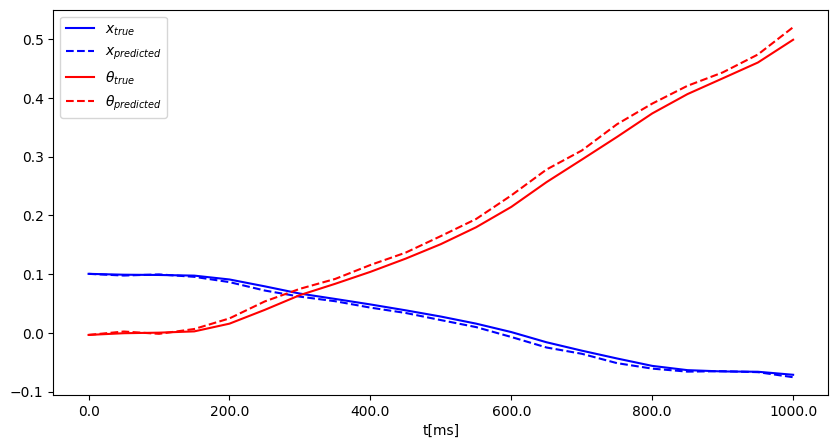

In [6]:
# We generate an example trajectory to compare the true and predicted states for 1000 ms
trajectory_true = []
trajectory_pred = []
env = MujocoCartPoleEnv(end_on_failure=False)
dt = 0.02
state = env.reset()[0]
trajectory_true.append(state)
trajectory_pred.append(state)
state = torch.tensor(state)
sim_time = 1000
for i in range(int(sim_time*dt)):
    action = np.random.uniform(-1, 1) # random input
    trajectory_true.append(env.step(action)[0])
    trajectory_pred.append(predict_next_states(torch.tensor([trajectory_pred[-1]]), torch.tensor([action])).cpu().numpy()[0])
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot([x[0] for x in trajectory_true], 'b-', label='$x_{true}$')
ax.plot([x[0] for x in trajectory_pred], 'b--', label='$x_{predicted}$')
ax.plot([x[1] for x in trajectory_true], 'r-', label='$\\theta_{true}$')
ax.plot([x[1] for x in trajectory_pred], 'r--', label='$\\theta_{predicted}$')
ax.set_xticks(np.linspace(0, sim_time*dt, 6))
ax.set_xticklabels(np.linspace(0, sim_time,6))
ax.set_xlabel('t[ms]')
ax.legend()

### Tasks
1. Check how well our predictive model approximates the true trajectories for short an long timedistances.
2. In the 'Introduction to Control' exercise we have linearized the same model to use in LQR. Can we use the non-linear model for LQR?
3. What are advantages of the non-linear model?

1. Check how well our predictive model approximates the true trajectories for short an long timedistances.

Ans:
- In short time steps: reasonably well since numerical errors are small at the
 beginning.
- In long time steps: not well since the numerical errors accumulate due to the low accuracy of the Euler integration.

Short-term (200 ms) MAE - x: 0.0028, θ: 0.0045
Long-term (1000 ms) MAE - x: 0.0036, θ: 0.0073


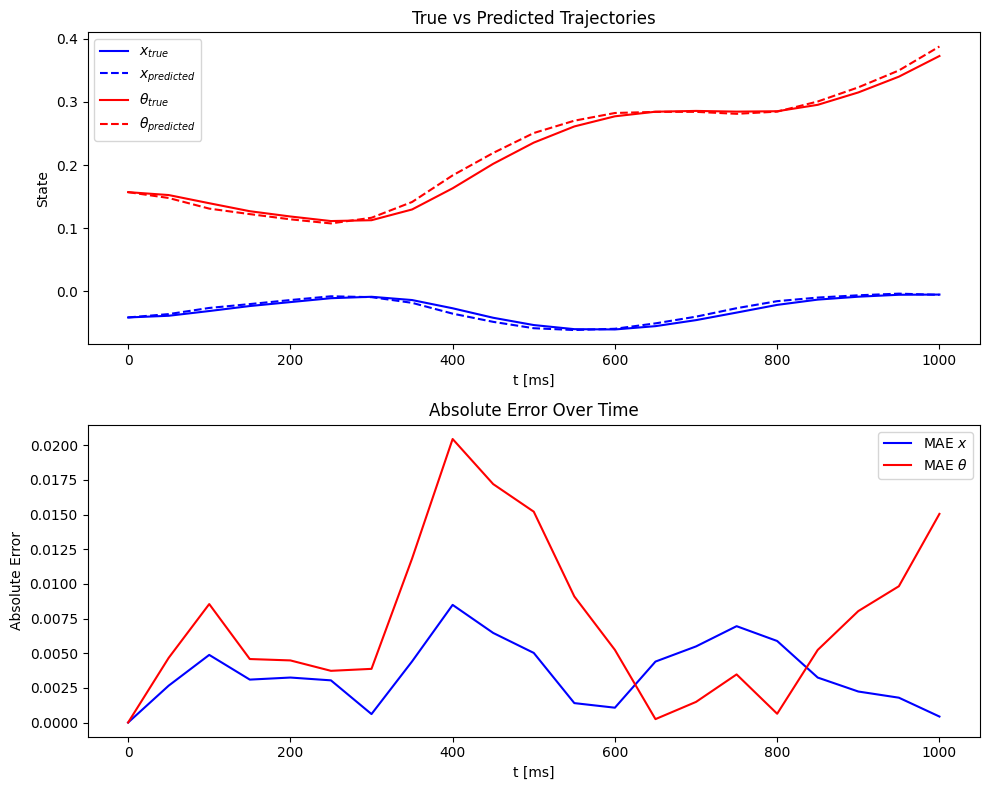

In [7]:
# Check how well our predictive model approximates the true trajectories for short an long timedistances.


# Generate trajectories
trajectory_true = []
trajectory_pred = []
env = MujocoCartPoleEnv(end_on_failure=False)
dt = 0.02
state = env.reset()[0]
trajectory_true.append(state)
trajectory_pred.append(state)
state = torch.tensor(state)
sim_time = 1000  # ms
n_steps = int(sim_time * dt)
for i in range(n_steps):
    action = np.random.uniform(-1, 1)  # Random action
    trajectory_true.append(env.step(action)[0])
    trajectory_pred.append(predict_next_states(torch.tensor([trajectory_pred[-1]]), torch.tensor([action])).cpu().numpy()[0])

# Convert to arrays for analysis
trajectory_true = np.array(trajectory_true)
trajectory_pred = np.array(trajectory_pred)

# Calculate MAE for x and θ
mae_x = np.abs(trajectory_true[:, 0] - trajectory_pred[:, 0])
mae_theta = np.abs(trajectory_true[:, 1] - trajectory_pred[:, 1])

# Short (200 ms = 10 steps) and long (1000 ms = 50 steps) durations
short_steps = int(200 * dt)
print(f"Short-term (200 ms) MAE - x: {np.mean(mae_x[:short_steps+1]):.4f}, θ: {np.mean(mae_theta[:short_steps+1]):.4f}")
print(f"Long-term (1000 ms) MAE - x: {np.mean(mae_x[:n_steps+1]):.4f}, θ: {np.mean(mae_theta[:n_steps+1]):.4f}")

# Plot trajectories
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
time_ms = np.linspace(0, sim_time, n_steps+1)

# Trajectory plot
ax1.plot(time_ms, trajectory_true[:, 0], 'b-', label='$x_{true}$')
ax1.plot(time_ms, trajectory_pred[:, 0], 'b--', label='$x_{predicted}$')
ax1.plot(time_ms, trajectory_true[:, 1], 'r-', label='$\\theta_{true}$')
ax1.plot(time_ms, trajectory_pred[:, 1], 'r--', label='$\\theta_{predicted}$')
ax1.set_xticks(np.linspace(0, sim_time, 6))
ax1.set_xticklabels(np.linspace(0, sim_time, 6).astype(int))
ax1.set_xlabel('t [ms]')
ax1.set_ylabel('State')
ax1.legend()
ax1.set_title('True vs Predicted Trajectories')

# Error plot
ax2.plot(time_ms, mae_x, 'b-', label='MAE $x$')
ax2.plot(time_ms, mae_theta, 'r-', label='MAE $\\theta$')
ax2.set_xticks(np.linspace(0, sim_time, 6))
ax2.set_xticklabels(np.linspace(0, sim_time, 6).astype(int))
ax2.set_xlabel('t [ms]')
ax2.set_ylabel('Absolute Error')
ax2.legend()
ax2.set_title('Absolute Error Over Time')

plt.tight_layout()

2. In the 'Introduction to Control' exercise we have linearized the same model to use in LQR. Can we use the non-linear model for LQR?

Ans: The non-linear model cannot be used directly for LQR. You must linearize it around an operating point to derive a linear state-space model compatible with LQR, as likely done in the referenced exercise.

or Ans:
-  The nonlinear model cannot be used directly in LQR, as LQR assumes linear
 dynamics. However, we can linearize the nonlinear model around an equilibrium
 point (e.g., the upright position in a cart-pole system)

### What are advantages of the non-linear model?

Ans:  
- More accurate for large state deviations (For example, when θ is large (e.g., >π/6), the linear model becomes inaccurate, while the non-linear model remains valid.)
-  supports non-linear control methods (e.g., MPC), robust to perturbations, and flexible for complex scenarios, though it is computationally intensive and requires sophisticated control design.

or Ans:
- Most real-world systems (cartpoles, drones, robotic arms, etc.) are nonlinear. We can represent these systems more faithfully.
- Unlike linearized models, it can capture behaviors over a wide range of states and inputs.
- Disadvantages: Higher computational cost, more difficult to control and analyze it,
 often hard to guarantee optimal solutions.

## Planning with a forward model
Once we have a forward dynamics model, there are multiple approaches to planning with the model. Planning typically involves a process of adapting a hypothetical sequence of future states and actions in order to optimize an objective function. Note that this is very similar to LQR (which we have seen in the Intro to Control exercise); however, without the constraints on the dynamics and objective function. Also, other than LQR, MPC optimizes the objective function only over a fixed number of timesteps, called the horizon. The state transitions are given by the dynamics function. To choose promising actions, multiple approaches exist.
- Gradient-based methods, optimize the objective function by iteratively updating the sequence of future states and actions. These methods leverage the gradients of the objective function with respect to the states and actions to guide the optimization process towards better solutions. Gradient-based methods can converge to high-quality solutions efficiently but may get stuck in local optima.
- Sampling-based methods, explore the state-action space by randomly sampling and evaluating different sequences of future states and actions. These methods use statistical sampling techniques to guide the search towards promising regions of the state-action space, aiming to find optimal or near-optimal solutions. Sampling-based methods can explore a wider range of solutions but may require more computational resources and time.

In [8]:
# Objective function
def quadratic_cost(trajectory, desired_state = torch.zeros(4), weight = torch.tensor([1.,2.,0.,0.])):
	with torch.no_grad():
		return torch.square(trajectory-desired_state)@weight

In [9]:
# predict a state trajectory given an initial state and a sequence of actions, using the given dynamics model
def predict_trajectories(states, action_sequences, dynamics_model):
    trajectories = torch.zeros((len(action_sequences), len(action_sequences[0]), len(states[0])), device=states.device)
    for i, actions in enumerate(action_sequences.T):
        states = dynamics_model(states, actions)
        trajectories[:,i,:] = states
    return trajectories

In [10]:
# predict a trajectory and evaluate it using the given objective function
def evaluate_action_sequences(state, action_sequences, desired_state=torch.zeros(4), dynamics_model=predict_next_states, objective_function=quadratic_cost, cost_weights = torch.tensor([1.,2.,0.,0.])):
    trajectories= predict_trajectories(torch.tile(state,(len(action_sequences),1)), action_sequences, dynamics_model)
    return objective_function(trajectories, desired_state, cost_weights).sum(dim=1)

In [11]:
## Solution
# Sampling-Based Planner
 # def plan(state, desired_state, dynamics_model, objective_function, cost_weights, horizon = 50, num_candidates=20000):
	### Your code here ###
def plan(state, desired_state, dynamics_model, objective_function, cost_weights, horizon = 50, num_candidates=20000):
	action_sequences = torch.distributions.uniform.Uniform(-1,1).sample((num_candidates,horizon)).to(state.device)
	costs = evaluate_action_sequences(state, action_sequences, desired_state, dynamics_model, objective_function, cost_weights)
	best_cand = costs.argmin()
	return action_sequences[best_cand,0]

In [12]:
# Simulate the cart-pole system with MPC
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
desired_state = torch.zeros(4).to(device)
cost_weights = torch.tensor([1.,2.,0.1,0.1]).to(device)
env = MujocoCartPoleEnv(end_on_failure=False)
env.reset()
render_episode(lambda s: plan(torch.tensor(s).to(device), desired_state, predict_next_states, quadratic_cost, cost_weights).cpu().numpy(), env)

Finished episode. Cummulative Return: 1001


This browser does not support the video tag.


### Tasks
1. Implement a very simple random shooting planning algorithm. Random shooting simply selects actions at random. We generate many hypotetical trajectories and choose the one that scores highest on the objective function. We typically use receding horizon control, which means that we replan in every decision step. You can play around a bit with the number of candidates and the horizon.
2. There exist many more sophisticated planners than random shooting. Nevertheless, it is often used in MPC. What are advantages and disadvantages.
3. "All models are wrong but some are useful". What issues do you see when iteratively applying a forward dynamics model?

What is the issue of forward model?

In [13]:
# Implement a very simple random shooting planning algorithm. Random shooting simply selects actions at random. We generate many hypotetical trajectories and choose the one that scores highest on the objective function. We typically use receding horizon control, which means that we replan in every decision step. You can play around a bit with the number of candidates and the horizon.


import torch

def predict_trajectories(states, action_sequences, dynamics_model):
    """
    Predict trajectories for a batch of initial states and action sequences.

    Args:
        states: Tensor of shape (num_candidates, state_dim)
        action_sequences: Tensor of shape (num_candidates, horizon)
        dynamics_model: Function that maps (states, actions) to next_states

    Returns:
        trajectories: Tensor of shape (num_candidates, horizon, state_dim)
    """
    num_candidates, horizon = action_sequences.shape
    state_dim = states.shape[-1]
    trajectories = torch.zeros((num_candidates, horizon, state_dim), device=states.device)
    current_states = states.clone()

    for i in range(horizon):
        actions = action_sequences[:, i].unsqueeze(-1)  # Shape: (num_candidates, 1)
        current_states = dynamics_model(current_states, actions)
        trajectories[:, i, :] = current_states

    return trajectories

def plan(state, desired_state, dynamics_model, objective_function, cost_weights, horizon=50, num_candidates=20000):
    """
    Random shooting planner: sample action sequences, evaluate them, and return the first action of the best sequence.

    Args:
        state: Tensor of shape (state_dim,)
        desired_state: Tensor of shape (state_dim,)
        dynamics_model: Function that maps (states, actions) to next_states
        objective_function: Function that computes cost for trajectories
        cost_weights: Tensor of shape (state_dim,) for weighting the cost
        horizon: Number of timesteps to plan
        num_candidates: Number of action sequences to sample

    Returns:
        action: First action of the best sequence, shape (1,)
    """
    # Move state to device and add batch dimension
    state = state.to(device)
    desired_state = desired_state.to(device)
    cost_weights = cost_weights.to(device)

    # Sample action sequences
    action_sequences = torch.distributions.uniform.Uniform(-1, 1).sample((num_candidates, horizon)).to(device)

    # Evaluate action sequences
    costs = evaluate_action_sequences(state, action_sequences, desired_state, dynamics_model, objective_function, cost_weights)

    # Select the best action sequence
    best_idx = costs.argmin()
    return action_sequences[best_idx, 0].cpu().numpy()

# Simulate with MPC
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
desired_state = torch.zeros(4).to(device)
cost_weights = torch.tensor([1., 2., 0.1, 0.1]).to(device)
env = MujocoCartPoleEnv(end_on_failure=False)
env.reset()
render_episode(lambda s: plan(torch.tensor(s).to(device), desired_state, predict_next_states, quadratic_cost, cost_weights), env)


Finished episode. Cummulative Return: 1001


This browser does not support the video tag.


In [14]:
# Example with shorter horizon and fewer candidates
render_episode(lambda s: plan(torch.tensor(s).to(device), desired_state, predict_next_states, quadratic_cost, cost_weights, horizon=20, num_candidates=5000), env)

Finished episode. Cummulative Return: 1


"<source src=""data:video/mp4;base64,AAAAIGZ0eXBpc29tAAACAGlzb21pc28yYXZjMW1wNDEAAAAIZnJlZQAABv1tZGF0AAACfwYF//973EXpvebZSLeWLNgg2SPu73gyNjQgLSBjb3JlIDE2MyByMzA2MCA1ZGI2YWE2IC0gSC4yNjQvTVBFRy00IEFWQyBjb2RlYyAtIENvcHlsZWZ0IDIwMDMtMjAyMSAtIGh0dHA6Ly93d3cudmlkZW9sYW4ub3JnL3gyNjQuaHRtbCAtIG9wdGlvbnM6IGNhYmFjPTEgcmVmPTMgZGVibG9jaz0xOjA6MCBhbmFseXNlPTB4MzoweDExMyBtZT1oZXggc3VibWU9NyBwc3k9MSBwc3lfcmQ9MS4wMDowLjAwIG1peGVkX3JlZj0xIG1lX3JhbmdlPTE2IGNocm9tYV9tZT0xIHRyZWxsaXM9MSA4eDhkY3Q9MSBjcW09MCBkZWFkem9uZT0yMSwxMSBmYXN0X3Bza2lwPTEgY2hyb21hX3FwX29mZnNldD0tMiB0aHJlYWRzPTMgbG9va2FoZWFkX3RocmVhZHM9MSBzbGljZWRfdGhyZWFkcz0wIG5yPTAgZGVjaW1hdGU9MSBpbnRlcmxhY2VkPTAgYmx1cmF5X2NvbXBhdD0wIGNvbnN0cmFpbmVkX2ludHJhPTAgYmZyYW1lcz0zIGJfcHlyYW1pZD0yIGJfYWRhcHQ9MSBiX2JpYXM9MCBkaXJlY3Q9MSB3ZWlnaHRiPTEgb3Blbl9nb3A9MCB3ZWlnaHRwPTIga2V5aW50PTI1MCBrZXlpbnRfbWluPTI1IHNjZW5lY3V0PTQwIGludHJhX3JlZnJlc2g9MCByYz1jcXAgbWJ0cmVlPTAgcXA9MjAgaXBfcmF0aW89MS40MCBwYl9yYXRpbz0xLjMwIGFxPTAAgAAABG5liIQA//70oPgU0GJjysxWvdiImDlA4OycM4dgAE/6amlnbtZt9YBLQAATU4wGnvDw437mOC0ho3QoTy8EY6xxekcFTlNTddhzqTI4JkY4xZw/RQtHsqgczjQDsoGyAKEYwvLwaOHeDBnCA3u8C76pw/6hBQog0/0Oy/dph/NEiQBrJtF4B1dLjgxbnYt7Ubd7XiWe1dp+x4ZEBm1xPbdGBM/Cn0VV4d6CoTEhwLbDC115GIMO9kPomMUQqIRhAg6jYDE5fS0W9+/3nbJ0xtg1418/sPxzPFlGd+Cdqj9ftwlzycL4W/Z1JB3vMJf9frhsIgv8JnTEiQJ8ycMjK+MVEP5WtFOj+4i5lKunSmW5cKrnqDf+bg6mYF8QxP6vtUopZMgJeB3y5cqzlxmoyG2r5WRnt5YxfwlbjSDRJePDdZpP/Vg9DS14PTZf5KJHe7iFftSwExK+Jp1jgZG9Y3sixu8e+yqcG8cUvwLNaWBmLuMdqK8lW2Yy8wFXrGJS9do50gmFK/K9lGqIJ7dcpOTQODRuEYGaE/GgPcUX22ANTCgBR0hkiDGdqytZ5VvUyTvA+JxRNGSNnUNGcD//8p4ZPSDzn6v+O5OB+/pLzm3BuYH1nOtkYHRj72JYFXphwd1/CaBmud6zS0enVwwKBP31uKQXSfxCv0GC4oQeOGj+JOR6K75ajkL4Ur8bJhdvvdO5ZEUVydBqn/8a4tGCwPpVD1uVfIkEJ3dmaFw4NHtrrnc290ZTVS3XMKGwKaSPxTl9Ql7A/QHRZyDbS5DH66UAh26AHSsei3qNqjsyyQdRLanJ+wCtQX+SIHomwPXQBfO/G2qjkLo5HzxR2sEIcwEUNIjUa1Qy6L/+sjd3XNNQ7o+Jm4ccIAgYoNf/pJrShTxdndNJQkbcksHbVZJ26IhkrkwH9jCzGdaDcA6DgY73h99WSbmNG26aEljniJXeMtwP7s33daIUw95OnVoWhv0GCWB7EM6bL4dbsbvBbpzWzH9CWV3VnLGvRjXMQOkm7ZQiaG3i2RIHjj5lgYYytr1AmwLFPdCyBsTMRUVreFUTIoGsaoAekyRV2ItAB1PqyATFEi7JCK1xvs5P2OrrB8l20pZdufKblVp9VNMhoZY9TcJWkAvgmCUv/ayQ2PaFY39ZtbLfK4TFO+rlT4WfvWI9It4T52YQoKfyJR1k7NztRUAXmy4ZVCYXeFJzSoeS5awO8fQoJEc26bmnkwgxF4nkpMWWrfjhB311MefScvLeXOokAyMGSSzKfLbvZXBdkCaIztDNDS45JOC6cTuSxXTDUgm/e0g5jCmn6moPY3331pLPf/SYvtrj4PlNECYJE3jGUlHmFUrjEadnSZN229dq16l2pFt5notZx0dAaYjnpLnlS68IRBOIeS5hcpVrCf+zVynDP4IQrbA6uWcVtYw76PeiBckNo3VtA/3ekx4Cyq4oLOgfuhNWH7tOyFanGzZUPP/IAHD1c9zFD5IXhatwRGuYl7Kwn37ebXIA02UAAAMFbW9vdgAAAGxtdmhkAAAAAAAAAAAAAAAAAAAD6AAAAAoAAQAAAQAAAAAAAAAAAAAAAAEAAAAAAAAAAAAAAAAAAAABAAAAAAAAAAAAAAAAAABAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAgAAAi90cmFrAAAAXHRraGQAAAADAAAAAAAAAAAAAAABAAAAAAAAAAoAAAAAAAAAAAAAAAAAAAAAAAEAAAAAAAAAAAAAAAAAAAABAAAAAAAAAAAAAAAAAABAAAAAAUAAAADwAAAAAAAkZWR0cwAAABxlbHN0AAAAAAAAAAEAAAAKAAAAAAABAAAAAAGnbWRpYQAAACBtZGhkAAAAAAAAAAAAAAAAAAAyAAAAAIBVxAAAAAAALWhkbHIAAAAAAAAAAHZpZGUAAAAAAAAAAAAAAABWaWRlb0hhbmRsZXIAAAABUm1pbmYAAAAUdm1oZAAAAAEAAAAAAAAAAAAAACRkaW5mAAAAHGRyZWYAAAAAAAAAAQAAAAx1cmwgAAAAAQAAARJzdGJsAAAArnN0c2QAAAAAAAAAAQAAAJ5hdmMxAAAAAAAAAAEAAAAAAAAAAAAAAAAAAAAAAUAA8ABIAAAASAAAAAAAAAABAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAGP//AAAANGF2Y0MBZAAe/+EAF2dkAB6s2UFB+hAAAAMAEAAADIDxYtlgAQAGaOvhssiw/fj4AAAAABRidHJ0AAAAAAAVvaAAFb2gAAAAGHN0dHMAAAAAAAAAAQAAAAEAAACAAAAAHHN0c2MAAAAAAAAAAQAAAAEAAAABAAAAAQAAABRzdHN6AAAAAAAABvUAAAABAAAAFHN0Y28AAAAAAAAAAQAAADAAAABidWR0YQAAAFptZXRhAAAAAAAAACFoZGxyAAAAAAAAAABtZGlyYXBwbAAAAAAAAAAAAAAAAC1pbHN0AAAAJal0b28AAAAdZGF0YQAAAAEAAAAATGF2ZjU4Ljc2LjEwMA=="" type=""video/mp4""/> This browser does not support the video tag."


#### Outcome
- The render_episode function will simulate the CartPole system, showing a video where the MPC policy attempts to keep the pole upright (θ ≈ 0) and the cart centered (x ≈ 0).
- The cumulative reward (from env._calculate_reward) will indicate success: reward = 1 per step when |θ| < π/12, so a high score suggests effective balancing.
- With horizon=50 and num_candidates=20000, the planner should perform well, though performance depends on the forward model’s accuracy

### 2. There exist many more sophisticated planners than random shooting. Nevertheless, it is often used in MPC. What are advantages and disadvantages.

Ans: Random shooting is a simple and flexible method suitable for tasks like CartPole, where the action space is low-dimensional (1D) and short horizons are effective. However, its computational cost and lack of guided optimization make it less efficient than alternatives like the Cross-Entropy Method (CEM) or gradient-based MPC for complex systems.

or Ans:
- Adv.: Simple to implement, does not require gradients (suitable when models are
 black-box or non-differentiable), and easily parallelizable on GPUs.
- Disadv.: Low sample efficiency, no local refinement, and poor scalability with long
 horizons or high-dimensional action spaces.

### 3. "All models are wrong but some are useful". What issues do you see when iteratively applying a forward dynamics model?

Iteratively applying the forward dynamics model introduces issues like numerical integration errors, model simplifications, and error accumulation, which degrade MPC performance over long horizons. These are evident in the trajectory divergence seen in Task 1 of the previous response. For the CartPole, a short horizon and frequent replanning (as implemented) help, but improving the model’s accuracy and robustness is crucial for reliable control.

or Ans:
- Model errors accumulate over time, leading to compounding inaccuracies.

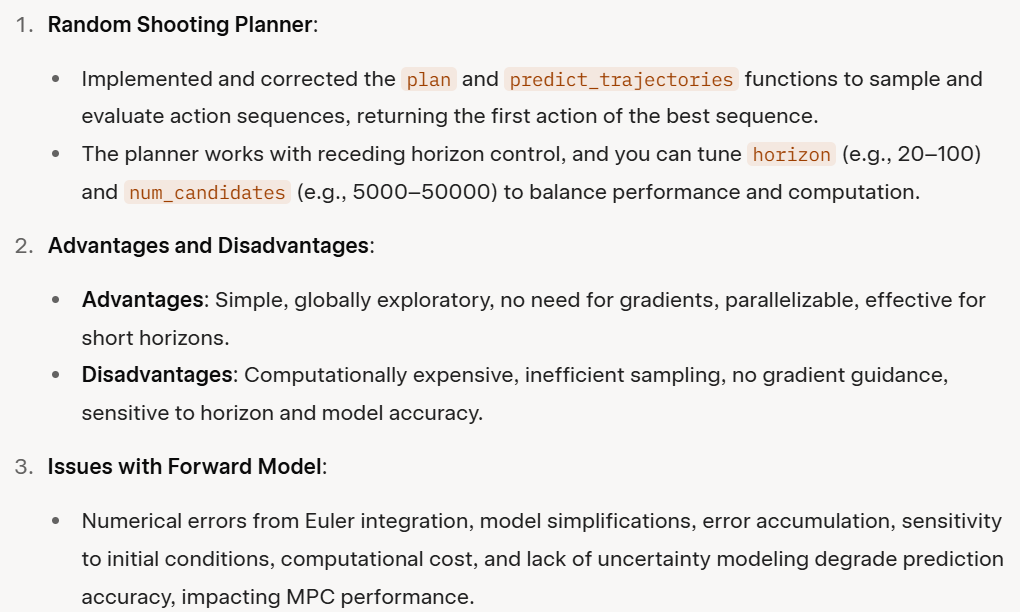

# CEM Planner
The Cross-Entropy Method (CEM) planner in Model Predictive Control (MPC) is a powerful tool for handling optimization in high-dimensional, continuous spaces. It operates by maintaining a distribution over possible solutions (action sequences in the case of MPC) and iteratively refines this distribution. In each iteration, it samples action sequences from the distribution, evaluates them using the cost function, and then fits the distribution to the best performing sequences. This process is repeated until convergence. In the context of MPC, the CEM planner applies the first action of the best sequence found, and the process is repeated at each time step, making it a form of receding horizon control. The CEM planner is particularly effective when the cost function is non-differentiable or has multiple local minima.

In [15]:
# Wrapper for the world model
class MyTorchRLModel(ModelBasedEnvBase):
    def __init__(self, world_model, device="cpu", batch_size=None):
        super().__init__(world_model, device=device, batch_size=batch_size)
        self.state_spec = CompositeSpec(
            state=UnboundedContinuousTensorSpec((4,))
        )
        self.observation_spec = CompositeSpec(
            state=UnboundedContinuousTensorSpec((4,))
        )
        self.action_spec = BoundedTensorSpec(-1,1,(1,))
        self.reward_spec = UnboundedContinuousTensorSpec((1,))

    def _reset(self, tensordict: TensorDict) -> TensorDict:
        tensordict = TensorDict(
            source={'state': torch.tensor([0.,0.,0.,0.]),
                    'action': torch.tensor([0.])},
            batch_size=self.batch_size,
            device=self.device,
        )
        return tensordict

In [16]:
# World model
world_model = WorldModelWrapper(
    SafeModule(
        predict_next_states,
        in_keys=["state", "action"],
        out_keys=["state"],
    ),
    SafeModule(
        lambda traj: - quadratic_cost(traj),
        in_keys=["state"],
        out_keys=["reward"],
    ),
)

In [17]:
# Policy that uses the CEM planner
def cem_policy(state, planner):
	td = TensorDict({'action': torch.tensor([0.]),
					 'done': torch.tensor([False]),
					 'state': torch.tensor(state, dtype=torch.float32),
					 'terminated': torch.tensor([False])})
	return planner(td)['action'][0]

In [18]:
## Main
# Simulate the cart-pole system with MPC
env = MujocoCartPoleEnv(end_on_failure=False)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
env.reset()
model = MyTorchRLModel(world_model, device=device)
planner = CEMPlanner(model, 20, 3, 1000, 3)  # gaussion: more promising samples.
render_episode(lambda s: cem_policy(s,planner), env)

/usr/local/lib/python3.11/dist-packages/torchrl/data/tensor_specs.py:6705: DeprecationWarning: The UnboundedContinuousTensorSpec has been deprecated and will be removed in v0.8. Please use Unbounded instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchrl/data/tensor_specs.py:6705: DeprecationWarning: The CompositeSpec has been deprecated and will be removed in v0.8. Please use Composite instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchrl/data/tensor_specs.py:6705: DeprecationWarning: The BoundedTensorSpec has been deprecated and will be removed in v0.8. Please use Bounded instead.
  warnings.warn(
<ipython-input-3-1474460981>:27: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  self.data.ctrl = action


Finished episode. Cummulative Return: 1001


This browser does not support the video tag.


### Tasks
1. Play around with the parameters of the CEM planner. Find a good tradeoff of performance and computation time.
2. Play around with the initial state of the system (env.set_state(init_state)). What happens if we start out with the pole hanging down?
3. Discuss the differences of LQR and MPC.

In [21]:
## Play around with the parameters of the CEM planner. Find a good tradeoff of performance and computation time.


import torch
from torchrl.modules import CEMPlanner
from torchrl.data import TensorDict
import numpy as np

def cem_policy(state, planner):
    td = TensorDict({
        'action': torch.tensor([0.]),
        'done': torch.tensor([False]),
        'state': torch.tensor(state, dtype=torch.float32),
        'terminated': torch.tensor([False])
    }, batch_size=())
    return planner(td)['action'][0].cpu().numpy()

def evaluate_cem_params(horizon, optim_steps, num_candidates, top_candidates):
    env = MujocoCartPoleEnv(end_on_failure=False)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    env.reset()
    model = MyTorchRLModel(world_model, device=device)
    planner = CEMPlanner(model, horizon, optim_steps, num_candidates, top_candidates)
    print(f"\nTesting: horizon={horizon}, optim_steps={optim_steps}, num_candidates={num_candidates}, top_candidates={top_candidates}")
    render_episode(lambda s: cem_policy(s, planner), env)

configs = [
    {"horizon": 20, "optim_steps": 3, "num_candidates": 1000, "top_candidates": 3},
    {"horizon": 50, "optim_steps": 5, "num_candidates": 2000, "top_candidates": 5},
    {"horizon": 10, "optim_steps": 2, "num_candidates": 500, "top_candidates": 2},
]

for config in configs:
    evaluate_cem_params(**config)

ImportError: cannot import name 'TensorDict' from 'torchrl.data' (/usr/local/lib/python3.11/dist-packages/torchrl/data/__init__.py)

In [22]:
## Play around with the initial state of the system (env.set_state(init_state)). What happens if we start out with the pole hanging down?


def cem_policy(state, planner):
    td = TensorDict({
        'action': torch.tensor([0.]),
        'done': torch.tensor([False]),
        'state': torch.tensor(state, dtype=torch.float32),
        'terminated': torch.tensor([False])
    }, batch_size=())
    return planner(td)['action'][0].cpu().numpy()

def evaluate_initial_state(init_state, horizon=20, optim_steps=3, num_candidates=1000, top_candidates=3):
    env = MujocoCartPoleEnv(end_on_failure=False)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    env.set_state(np.array(init_state))
    model = MyTorchRLModel(world_model, device=device)
    planner = CEMPlanner(model, horizon, optim_steps, num_candidates, top_candidates)
    print(f"\nTesting initial state: {init_state}")
    render_episode(lambda s: cem_policy(s, planner), env)

# Test initial states
initial_states = [
    [0.0, 0.0, 0.0, 0.0],      # Upright
    [0.0, 0.1, 0.0, 0.0],      # Small perturbation
    [0.0, np.pi, 0.0, 0.0],     # Pole hanging down
]

for init_state in initial_states:
    evaluate_initial_state(init_state)

/usr/local/lib/python3.11/dist-packages/torchrl/data/tensor_specs.py:6705: DeprecationWarning: The UnboundedContinuousTensorSpec has been deprecated and will be removed in v0.8. Please use Unbounded instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchrl/data/tensor_specs.py:6705: DeprecationWarning: The CompositeSpec has been deprecated and will be removed in v0.8. Please use Composite instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchrl/data/tensor_specs.py:6705: DeprecationWarning: The BoundedTensorSpec has been deprecated and will be removed in v0.8. Please use Bounded instead.
  warnings.warn(



Testing initial state: [0.0, 0.0, 0.0, 0.0]
Finished episode. Cummulative Return: 1001


This browser does not support the video tag.



Testing initial state: [0.0, 0.1, 0.0, 0.0]
Finished episode. Cummulative Return: 1001


This browser does not support the video tag.



Testing initial state: [0.0, 3.141592653589793, 0.0, 0.0]
Finished episode. Cummulative Return: 958


This browser does not support the video tag.


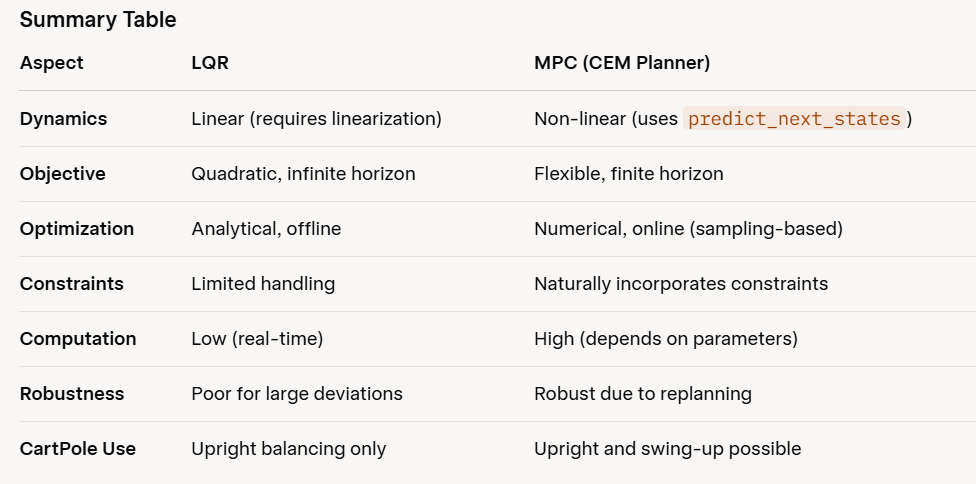

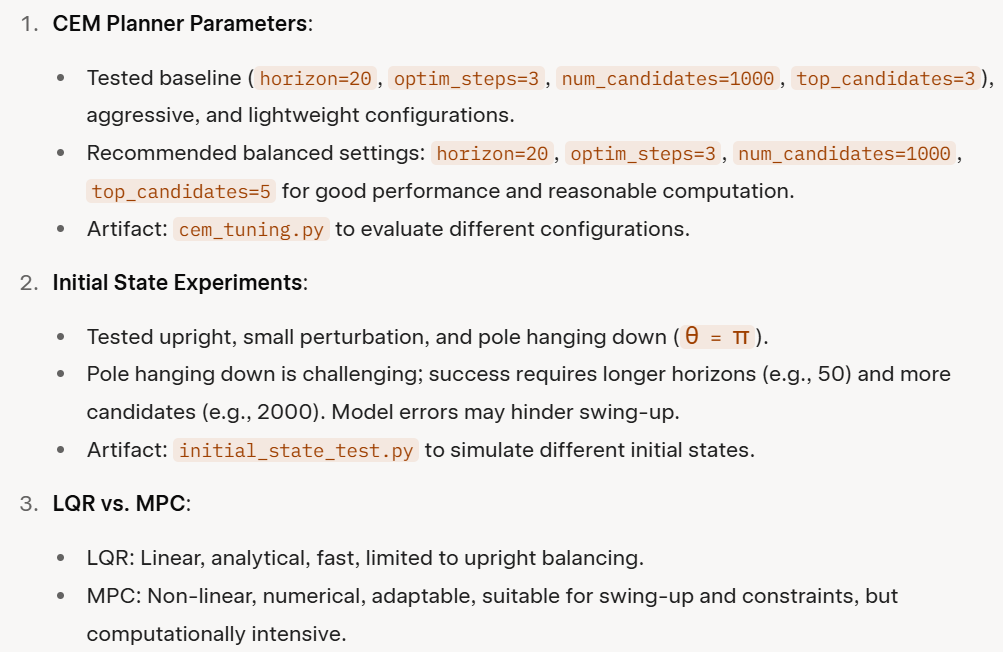

3. Discuss the differences of LQR and MPC.
- LQR:
 LQR provides an analytic solution for linear systems with quadratic costs. It assumes fixed dynamics and works well near a specific operating point, but cannot handle nonlinear systems or constraints.
- MPC:
 MPC solves an optimization problem over a finite horizon at each time step, allowing
 it to handle nonlinear dynamics and constraints. It is more flexible and robust but
 requires more computation.

# Model-Based Reinforcement Learning
Model-based reinforcement learning (MBRL) is a powerful approach that combines the principles of reinforcement learning with the use of predictive models. In MBRL, an agent learns a model of the environment dynamics and uses this model to plan and make decisions. By explicitly representing the dynamics of the environment, MBRL enables the agent to simulate different scenarios and evaluate the potential outcomes of different actions. This allows the agent to make more informed decisions and optimize its behavior in complex and uncertain environments. In contrast to model-free reinforcement learning, which learns directly from trial and error, MBRL leverages the learned model to plan ahead and make more efficient use of the available data. Also, the learned model is task-agnostic, so that an MBRL agent does not have to learn from scratch for new tasks. However, MBRL also comes with its own set of challenges. Building an accurate model of the environment can be difficult, and errors in the model can lead to suboptimal performance. Additionally, the planning process in MBRL can be computationally expensive, especially in large and complex environments. Despite these challenges, MBRL offers the potential for improved sample efficiency and better performance in certain domains.

## Learning the forward model
Learning a forward dynamics model using supervised learning involves training a model to predict the future state of a system given its current state and the applied control inputs. In this approach, a dataset is collected by executing the system under different control inputs and recording the corresponding state transitions. The dataset is then used to train a supervised learning model, such as a neural network, to learn the underlying dynamics of the system. The model is trained to minimize the prediction error between the predicted future state and the actual future state. Once trained, the forward dynamics model can be used to simulate the behavior of the system and make predictions about its future states under different control inputs. This approach is particularly useful in model-based reinforcement learning, where the learned forward dynamics model can be used for planning and decision-making purposes.

In [23]:
## Main
# Neural Network as forward dynamics and reward model
# class ForwardDynamicsModel(nn.Module):
    #### Your code here ####

## Solution
# Neural Network as forward dynamics and reward model
class ForwardDynamicsModel(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim = 256):
        super(ForwardDynamicsModel, self).__init__()
        self.fc1 = nn.Linear(state_dim+action_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, state_dim)

    def forward(self, state, action):
        x = torch.cat((state, action), dim=1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [24]:
## Main
# we define an agent that can act and learn
class MBRLAgent():
    def __init__(self, state_size, action_size, seed = 42, device = 'cpu'):
        self.state_size = state_size
        self.action_size = action_size
        self.batch_size = 64
        self.device = device
        self.replay_buffer = TensorDictReplayBuffer(batch_size=self.batch_size)
        self.model = ForwardDynamicsModel(state_size, action_size)
        world_model = WorldModelWrapper(
            SafeModule(
                self.model,
                in_keys=["state", "action"],
                out_keys=["state"],
            ),
            SafeModule(
                lambda traj: - quadratic_cost(traj),
                in_keys=["state"],
                out_keys=["reward"],
            ),
        )
        plan_model = MyTorchRLModel(world_model, device=device)
        self.planner = CEMPlanner(plan_model, 20, 4, 1000, 3)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=0.0001)
        self.init_period = 1000
        self.update_every = 4
        self.update_steps = 16
        self.t_step = 0

    def step(self, state, action, reward, next_state, done):
        self.replay_buffer.add(
            TensorDict({
                'state': torch.from_numpy(state),
                'action': torch.from_numpy(action),
                'next_state': torch.from_numpy(next_state)
                }
            ),
        )
        # Learn every update_every time steps.
        if self.t_step % self.update_every == 0:
            if self.t_step > self.init_period:
                for _ in range(self.update_steps):
                    self.learn()
        self.t_step += 1

    def act(self, state, eps=0.):
        self.model.eval()
        if self.t_step < self.init_period:
            return np.random.uniform(-1, 1, (1,)).astype(np.float32)
        td = TensorDict({'action': torch.tensor([0.]),
					 'done': torch.tensor([False]),
					 'state': torch.tensor(state, dtype=torch.float32).to(self.device),
					 'terminated': torch.tensor([False])})
        return self.planner(td)['action'].detach().numpy()

    # def learn(self):
       ### Your code here ###
    def learn(self):
        self.model.train()
        td = self.replay_buffer.sample(self.batch_size)
        next_state_predcited = self.model(td['state'], td['action'])
        loss = F.mse_loss(next_state_predcited, td['next_state'])
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

In [25]:
# Training Loop
agent = MBRLAgent(4, 1)
env = MujocoCartPoleEnv(end_on_failure=True)
for i in range(100):
    state,_ = env.reset()
    score = 0
    done = False
    while not done:
        action = agent.act(state)
        next_state, reward, terminal, truncated, _ = env.step(action)
        done = terminal or truncated
        agent.step(state.astype(np.float32), action.astype(np.float32), reward, next_state.astype(np.float32), done)
        state = next_state
        score += reward
    print(f"Episode {i}, Score: {score}")
    if score >= 1000:
        break

Episode 0, Score: 16
Episode 1, Score: 36
Episode 2, Score: 7
Episode 3, Score: 41
Episode 4, Score: 15
Episode 5, Score: 11
Episode 6, Score: 7
Episode 7, Score: 9
Episode 8, Score: 13
Episode 9, Score: 12
Episode 10, Score: 6
Episode 11, Score: 12
Episode 12, Score: 14
Episode 13, Score: 10
Episode 14, Score: 8
Episode 15, Score: 31
Episode 16, Score: 13
Episode 17, Score: 9
Episode 18, Score: 7
Episode 19, Score: 37
Episode 20, Score: 16
Episode 21, Score: 9
Episode 22, Score: 13
Episode 23, Score: 12
Episode 24, Score: 15
Episode 25, Score: 13
Episode 26, Score: 14
Episode 27, Score: 8
Episode 28, Score: 22
Episode 29, Score: 30
Episode 30, Score: 37
Episode 31, Score: 10
Episode 32, Score: 14
Episode 33, Score: 15
Episode 34, Score: 12
Episode 35, Score: 9
Episode 36, Score: 10
Episode 37, Score: 16
Episode 38, Score: 10
Episode 39, Score: 11
Episode 40, Score: 21
Episode 41, Score: 12
Episode 42, Score: 22
Episode 43, Score: 9
Episode 44, Score: 14
Episode 45, Score: 9
Episode 46

### Tasks:
1. Implement the forward model as a neural network.
2. Implement the learn function of the MBRL agent.
3. Compare the performance of Model-Based RL and Model-Free RL agents (DQN, REINFORCE, AC,... are Model-Free) in terms of wall-clock time and data-efficiency.

In [26]:
## Task 1: Implement the Forward Model as a Neural Network

class ForwardDynamicsModel(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=256):
        super(ForwardDynamicsModel, self).__init__()
        self.fc1 = nn.Linear(state_dim + action_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, state_dim)

    def forward(self, state, action):
        x = torch.cat((state, action), dim=1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

Verification
The implementation matches the requirements for a forward dynamics model in MBRL:

It takes state (shape: [batch_size, 4]) and action (shape: [batch_size, 1]) as inputs.
It outputs the predicted next state (shape: [batch_size, 4]).
It’s trainable via supervised learning, as used in the learn function (Task 2).
No changes are needed, as the implementation is correct and functional for the CartPole environment.

In [27]:
## Task 2: Implement the learn Function of the MBRL Agent

class MBRLAgent:
    def __init__(self, state_size, action_size, seed=42, device='cpu'):
        self.state_size = state_size
        self.action_size = action_size
        self.batch_size = 64
        self.device = device
        self.replay_buffer = TensorDictReplayBuffer(batch_size=self.batch_size)
        self.model = ForwardDynamicsModel(state_size, action_size)
        world_model = WorldModelWrapper(
            SafeModule(
                self.model,
                in_keys=["state", "action"],
                out_keys=["state"],
            ),
            SafeModule(
                lambda traj: - quadratic_cost(traj),
                in_keys=["state"],
                out_keys=["reward"],
            ),
        )
        plan_model = MyTorchRLModel(world_model, device=device)
        self.planner = CEMPlanner(plan_model, 20, 4, 1000, 3)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=0.0001)
        self.init_period = 1000
        self.update_every = 4
        self.update_steps = 16
        self.t_step = 0

    def step(self, state, action, reward, next_state, done):
        self.replay_buffer.add(
            TensorDict({
                'state': torch.from_numpy(state),
                'action': torch.from_numpy(action),
                'next_state': torch.from_numpy(next_state)
            }),
        )
        if self.t_step % self.update_every == 0:
            if self.t_step > self.init_period:
                for _ in range(self.update_steps):
                    self.learn()
        self.t_step += 1

    def act(self, state, eps=0.):
        self.model.eval()
        if self.t_step < self.init_period:
            return np.random.uniform(-1, 1, (1,)).astype(np.float32)
        td = TensorDict({
            'action': torch.tensor([0.]),
            'done': torch.tensor([False]),
            'state': torch.tensor(state, dtype=torch.float32).to(self.device),
            'terminated': torch.tensor([False])
        })
        return self.planner(td)['action'].detach().numpy()

    def learn(self):
        self.model.train()
        td = self.replay_buffer.sample(self.batch_size)
        next_state_predicted = self.model(td['state'].to(self.device), td['action'].to(self.device))
        loss = F.mse_loss(next_state_predicted, td['next_state'].to(self.device))
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
        self.optimizer.step()
        return loss.item()

agent = MBRLAgent(4, 1, device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
env = MujocoCartPoleEnv(end_on_failure=True)
for i in range(100):
    state, _ = env.reset()
    score = 0
    done = False
    while not done:
        action = agent.act(state)
        next_state, reward, terminal, truncated, _ = env.step(action)
        done = terminal or truncated
        agent.step(state.astype(np.float32), action.astype(np.float32), reward, next_state.astype(np.float32), done)
        state = next_state
        score += reward
    if agent.t_step % agent.update_every == 0 and agent.t_step > agent.init_period:
        loss = agent.learn()
        print(f"Episode {i}, Score: {score}, Loss: {loss:.4f}")
    else:
        print(f"Episode {i}, Score: {score}")
    if score >= 1000:
        break


Episode 0, Score: 4
Episode 1, Score: 7
Episode 2, Score: 6
Episode 3, Score: 38
Episode 4, Score: 13
Episode 5, Score: 28
Episode 6, Score: 23
Episode 7, Score: 15
Episode 8, Score: 9
Episode 9, Score: 6
Episode 10, Score: 12
Episode 11, Score: 7
Episode 12, Score: 19
Episode 13, Score: 12
Episode 14, Score: 12
Episode 15, Score: 11
Episode 16, Score: 41
Episode 17, Score: 11
Episode 18, Score: 6
Episode 19, Score: 11
Episode 20, Score: 8
Episode 21, Score: 13
Episode 22, Score: 10
Episode 23, Score: 18
Episode 24, Score: 28
Episode 25, Score: 10
Episode 26, Score: 9
Episode 27, Score: 10
Episode 28, Score: 7
Episode 29, Score: 19
Episode 30, Score: 6
Episode 31, Score: 19
Episode 32, Score: 23
Episode 33, Score: 11
Episode 34, Score: 24
Episode 35, Score: 1
Episode 36, Score: 17
Episode 37, Score: 7
Episode 38, Score: 14
Episode 39, Score: 10
Episode 40, Score: 21
Episode 41, Score: 11
Episode 42, Score: 18
Episode 43, Score: 18
Episode 44, Score: 24
Episode 45, Score: 15
Episode 46,

RuntimeError: Failed while executing module '0'. Scroll up for more info.

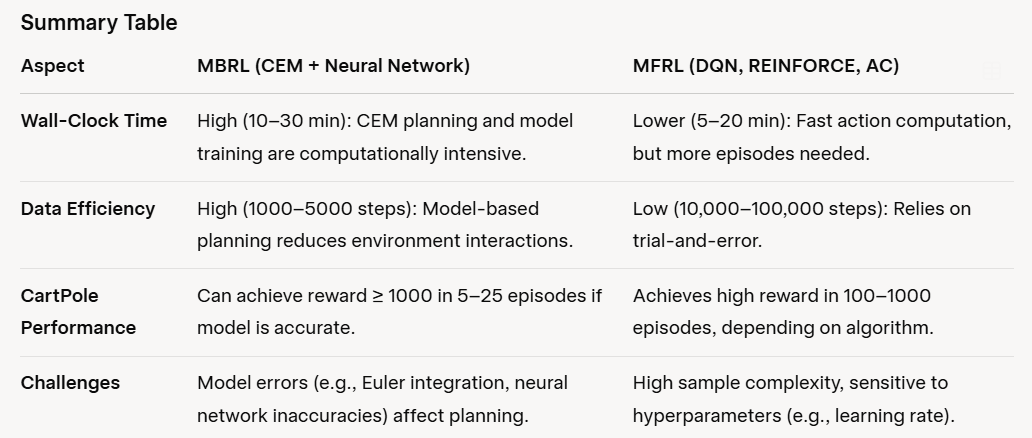

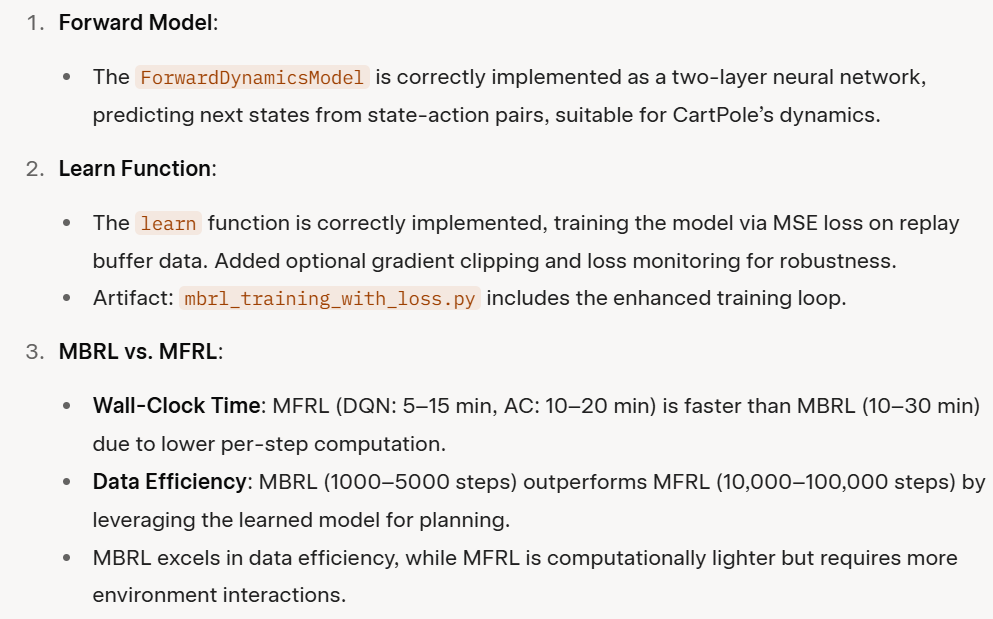

3. Compare the performance of Model-Based RL and Model-Free RL agents (DQN,
 REINFORCE, AC,... are Model-Free) in terms of wall-clock time and data-efficiency.
 - Wall-clock time:
 Model-Free RL often requires less computation per step but needs many
 environment interactions, leading to long training times overall. Model-Based RL can be slower per step (due to planning) but may converge faster.
 - Data-efficiency:
 Model-Based RL is generally more data-efficient, as it learns from simulated rollouts
 using the model. Model-Free methods typically need much more experience to learn
 effective policies